# Лабораторная работа 4
# Правильный многоугольник Рело. Векторизация вычислений в numpy



Космпьютерная математика 2, ММФ, БГУ


__Выполнил: Нестерук Кирилл__   
__Курс: 1__   
__Группа: 5__

## Задание 4.1

### Этап 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
n = 3 # количество вершин треугольника Рело
center = np.array([0,0]) # координаты центра треугольника Рело
r = 10. # ширина треугольника Рело
N = 100 # количество точек для описания одной стороны треугольника Рело

In [3]:
l = r # !!! равенство справедливо только для треугольника Рело


In [4]:
R = l/(2*np.sin(np.pi/n))


In [5]:
t = np.arange(0,2*np.pi,2*np.pi/n)
vertices = center + R*np.transpose([np.cos(t), np.sin(t)])
vertices


array([[ 5.77350269,  0.        ],
       [-2.88675135,  5.        ],
       [-2.88675135, -5.        ]])

In [6]:
vertices[0,0], vertices[0,:], vertices[:,1]


(np.float64(5.773502691896258),
 array([5.77350269, 0.        ]),
 array([ 0.,  5., -5.]))

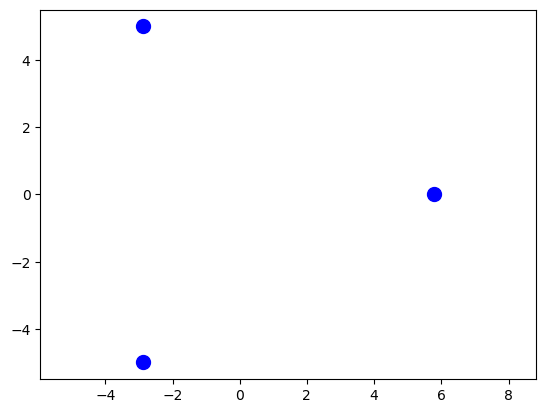

In [7]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.axis('equal');

### Этап 2

In [8]:
alpha = 2*np.pi/n
beta = alpha/2

In [9]:
angle = np.linspace(-beta/2, beta/2, N)

In [11]:
side0 = vertices[0] + r*np.transpose([np.cos(np.pi + angle), np.sin(np.pi + angle)])


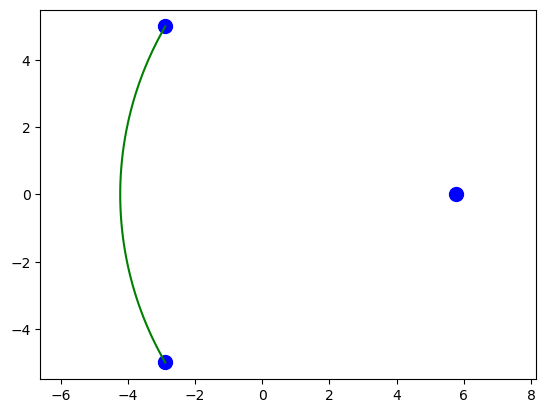

In [12]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'g-',markersize=20)
plt.axis('equal');


In [13]:
side1 = vertices[1] + r*np.transpose([np.cos(np.pi + angle + alpha), np.sin(np.pi + angle + alpha)])


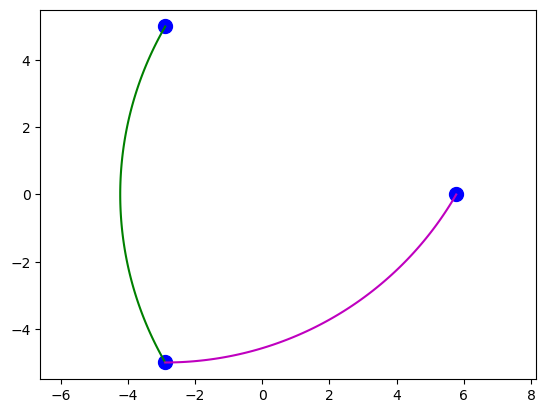

In [14]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(side0[:,0],side0[:,1],'g-',markersize=20)
plt.plot(side1[:,0],side1[:,1],'m-',markersize=20)
plt.axis('equal');

### Этап 3

In [15]:
list_sides = [vertices[i] +
 r*np.transpose([np.cos(angle + np.pi + i*alpha),
 np.sin(angle + np.pi + i*alpha)])
 for i in range(n)]


In [16]:
sides = np.concatenate(list_sides)

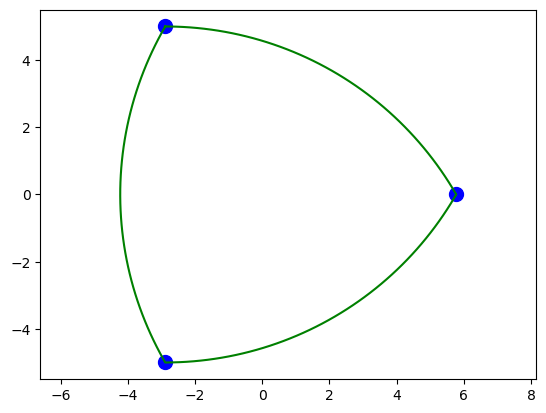

In [17]:
plt.plot(vertices[:,0],vertices[:,1],'b.',markersize=20)
plt.plot(sides[:,0],sides[:,1],'g-',markersize=20)
plt.axis('equal');


## Задание 4.2

In [21]:
def build_Relo_polygon(n, center, r, N):
    
    assert n % 2 == 1 and n > 2, "n должно быть нечётным числом > 2"
    assert r > 0, "r должна быть положительной"
    assert N > 0, "N должно быть натуральным числом"

    alpha = 2 * np.pi / n
    
    # Правильная формула для длины стороны
    l = r / (2 * np.cos(np.pi / n))
    
    # Радиус описанной окружности правильного многоугольника
    R_poly = l / (2 * np.sin(np.pi / n))
    # Упрощённо: R_poly = r / (2 * np.sin(2 * np.pi / n))

    # Вершины правильного n-угольника (используем R_poly, а не r!)
    t = np.arange(0, 2 * np.pi, alpha)
    vertices = center + R_poly * np.transpose([np.cos(t), np.sin(t)])

    # Угол для дуги
    beta = alpha / 2
    angle = np.linspace(-beta / 2, beta / 2, N)

    # Стороны
    list_sides = [
        vertices[i] + r * np.transpose([np.cos(angle + np.pi + i * alpha), np.sin(angle + np.pi + i * alpha)]) 
        for i in range(n)
    ]

    sides = np.concatenate(list_sides)
    return sides

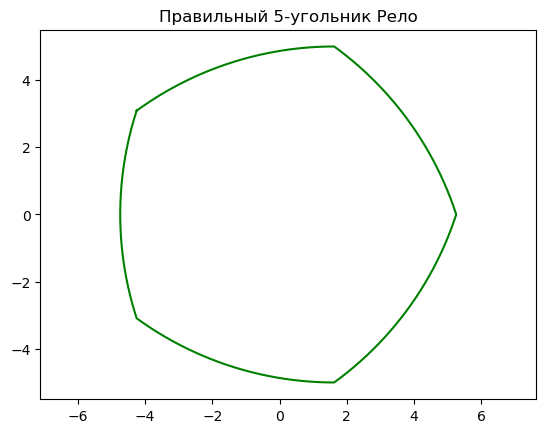

In [22]:

center = np.array([0, 0])
r = 10
N = 200

sides5 = build_Relo_polygon(5, center, r, N)

plt.plot(sides5[:, 0], sides5[:, 1], 'g-')
plt.axis('equal')
plt.title("Правильный 5-угольник Рело")
plt.show()

### Задание 4.3 

In [31]:
# relo.py
import numpy as np

def regular_polygon_Relo(
    n: int = 3,
    center: np.ndarray = np.array([0, 0]),
    r: float = 1.0,
    N: int = 100
) -> np.ndarray:
    """
    Возвращает матрицу точек границы правильного многоугольника Рело.

    Параметры:
    n : int (нечётное, >2) — количество вершин
    center : np.ndarray — центр фигуры [x, y]
    r : float — ширина фигуры (>0)
    N : int — количество точек на одну сторону (>0)

    Возвращает:
    np.ndarray — массив формы (n*N, 2) с координатами точек границы.
    """
    assert isinstance(n, int) and n > 2 and n % 2 == 1, "n должно быть нечётным целым >2"
    assert isinstance(center, np.ndarray) and center.shape == (2,), "center должен быть [x, y]"
    assert isinstance(r, (int, float)) and r > 0, "r > 0"
    assert isinstance(N, int) and N > 0, "N > 0"

    alpha = 2 * np.pi / n
    
    # ПРАВИЛЬНАЯ формула для радиуса описанной окружности
    R = r / (2 * np.sin(2 * np.pi / n))
    
    # Вершины правильного n-угольника (используем R, а не r!)
    t = np.arange(0, 2 * np.pi, alpha)
    vertices = center + R * np.transpose([np.cos(t), np.sin(t)])

    beta = alpha / 2
    angle = np.linspace(-beta / 2, beta / 2, N)

    list_sides = [
        vertices[i] + r * np.transpose([
            np.cos(angle + np.pi + i * alpha),
            np.sin(angle + np.pi + i * alpha)
        ])
        for i in range(n)
    ]

    return np.concatenate(list_sides)

In [32]:
print(regular_polygon_Relo.__annotations__)
print(regular_polygon_Relo.__doc__)

{'n': <class 'int'>, 'center': <class 'numpy.ndarray'>, 'r': <class 'float'>, 'N': <class 'int'>, 'return': <class 'numpy.ndarray'>}

Возвращает матрицу точек границы правильного многоугольника Рело.

Параметры:
n : int (нечётное, >2) — количество вершин
center : np.ndarray — центр фигуры [x, y]
r : float — ширина фигуры (>0)
N : int — количество точек на одну сторону (>0)

Возвращает:
np.ndarray — массив формы (n*N, 2) с координатами точек границы.



### задание 4.4

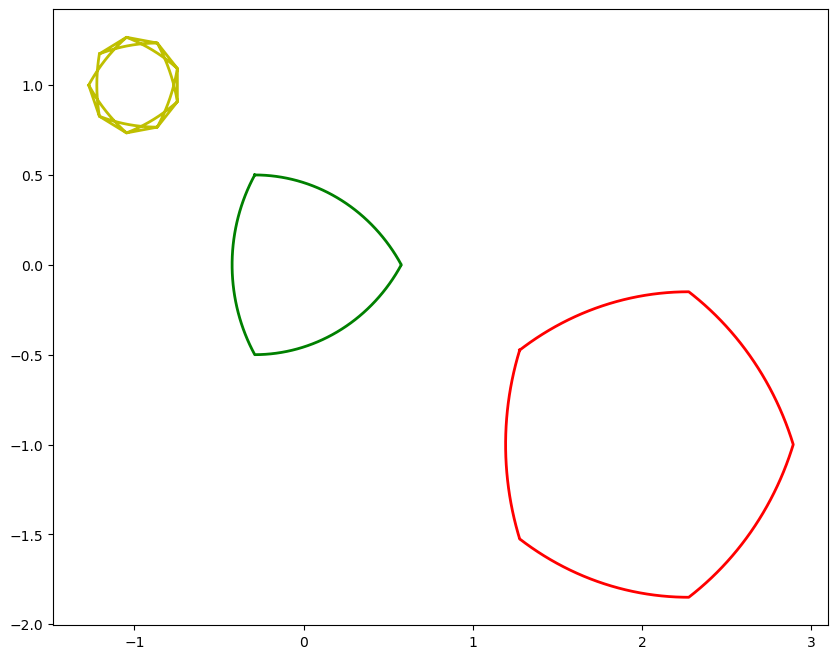

In [35]:
sides1 = regular_polygon_Relo(9, np.array([-1, 1]), 1, 100)
sides2 = regular_polygon_Relo(3, np.array([0, 0]), 1, 100)  # вместо None
sides3 = regular_polygon_Relo(5, np.array([2, -1]), 1.7, 100)  # вместо None
plt.figure(figsize=(10, 8))
plt.plot(sides1[:, 0], sides1[:, 1], 'y-', linewidth=2, label='n=9, center=(-1,1)')
plt.plot(sides2[:, 0], sides2[:, 1], 'g-', linewidth=2, label='n=3, center=(0,0)')
plt.plot(sides3[:, 0], sides3[:, 1], 'r-', linewidth=2, label='n=5, center=(2,-1)')
plt.show()